In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 
sys.path.append("../")

import evaluate
import checkpoint
import generate_data

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Loss

Best Validation Loss: 0.041


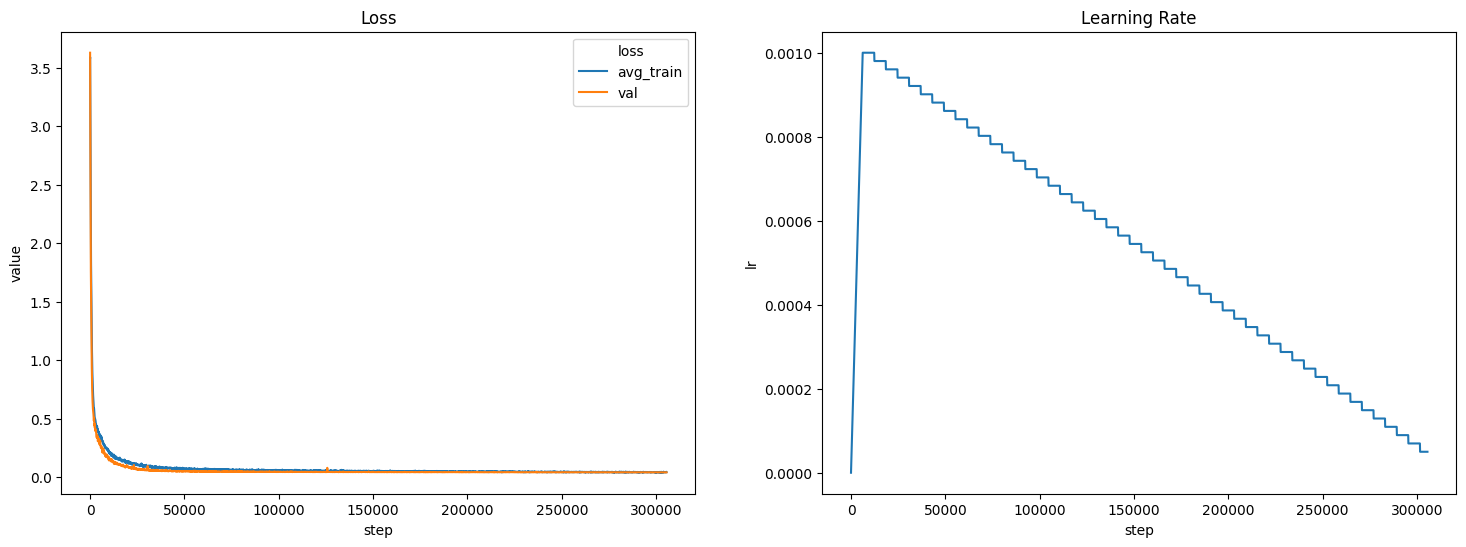

In [2]:
cp = checkpoint.CheckPoint("../models/MLC_data200k_nepoch50_best.pt", device=DEVICE)
fig, ax = plt.subplots(1, 2, figsize=(18,6))
ax[0] = cp.plot_loss(ax[0])
_ = ax[0].set_title("Loss")
ax[1] = cp.plot_learning_rate(ax[1])
_ = ax[1].set_title("Learning Rate")
print(f'Best Validation Loss: {cp.checkpoint["best_val_loss"]:.3f}')

### Accuracy

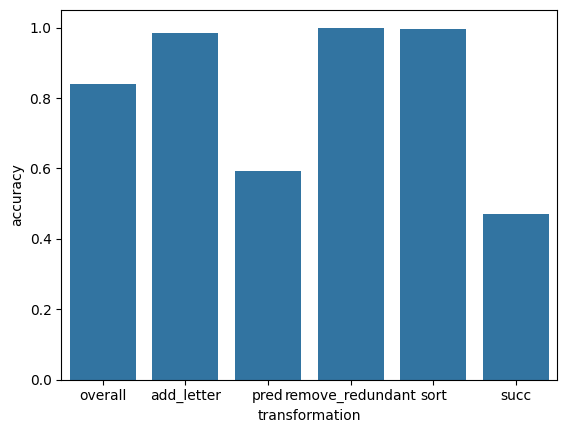

In [3]:
val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=["overall","add_letter","pred","remove_redundant","sort","succ"], var_name="transformation", value_name="accuracy")
_ = sns.barplot(val_acc[val_acc["epoch"]==13], x="transformation", y="accuracy")

Best Validation Accuracy: 0.843


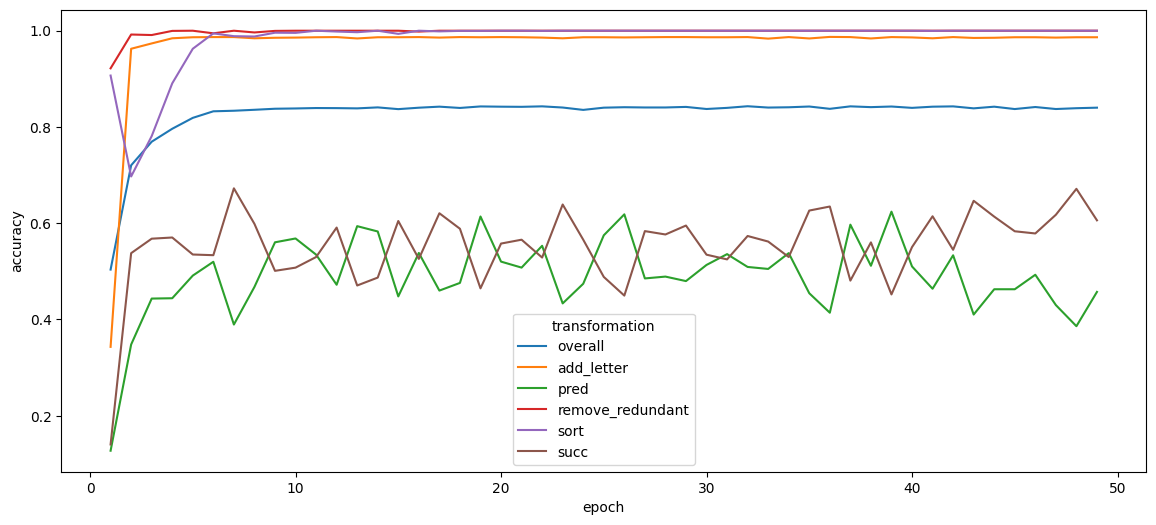

In [4]:
val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=["overall","add_letter","pred","remove_redundant","sort","succ"], var_name="transformation", value_name="accuracy")
print(f"Best Validation Accuracy: {val_acc.loc[val_acc["transformation"] =="overall","accuracy"].max():.3f}")
_ = plt.figure(figsize=(14,6))
_ = sns.lineplot(val_acc, x="epoch", y="accuracy", hue="transformation")

### Error Analysis

In [6]:
net = cp.load_model()
_, val = cp.load_dataloaders("../data/base_probs")

Loading model that has completed (or started) 50 of 50 epochs
	batch size: 25
	number of steps:305,600
	best val loss achieved: 0.0414
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Loading training (148,281 samples) and validation (16,476 samples) dataloaders.


### Displaying False Predictions

In [13]:
for i, batch in enumerate(val):
    if i > 10:
        break
    preds = evaluate.predict(batch, net, val.dataset.langs, 20, eval_type="max")
    print("False Predictions:\n---------------------------------------------------------------------------------------")
    for i in range(len(batch["yq"])):
        true = batch["yq"][i]
        pred = preds[i]
        if true != pred:
            print(f"Transformation type: {batch["transformation"][i]}")
            xq_context = " ".join(batch["xq_context"][i])
            xq_context = xq_context.replace("SOS", "|").replace("IO", "->")
            print(xq_context)
            print(f"True: {" ".join(true)}\t\tPredicted: {" ".join(pred)}\n")

False Predictions:
---------------------------------------------------------------------------------------
Transformation type: remove_redundant
a b c d j f g h i n k p m t o r e q s y l v w x u z | o o r e -> o r e | d d j f g
True: d j f g		Predicted: d f g

Transformation type: sort
a b c d j f g h i n k p m t o r e q s y l v w x u z | y z v w x u l -> y l v w x u z | t o q e r s y
True: t o r e q s y		Predicted: o p q r s t

Transformation type: extend_sequence
a b t d e x g h i j k l m n o f q r s c u v w p y z | s c u v w -> s c u v w p | m n o
True: m n o f		Predicted: m n o p

Transformation type: sort
a b t d e x g h i j k l m n o f q r s c u v w p y z | k h i j g -> g h i j k | t b a d e
True: a b t d e		Predicted: a b c d e

Transformation type: remove_redundant
a b y d e f g h i j k l m n o p q r s t u v w x c z | o p p q r -> o p q r | y d d e f g
True: y d e f g		Predicted: d e f g

Transformation type: succ
a b t d e x g h i j k l m n o f q r s c u v w p y z | d e x g h 

### Classifying Errors

In [ ]:
from collections import Counter
pred_errors, succ_errors = [], []

for batch in val:
    preds = evaluate.predict(batch, net, val.dataset.langs, 20, eval_type="max")
    for i, _ in enumerate(batch["yq"]):
        true = batch["yq"][i]
        pred = preds[i]
        if true != pred:
            if batch["transformation"][i] == "pred":
                try:
                    trans_type_found = False
                    for trans_name, trans_func in generate_data.TRANSFORMATIONS.items():
                        applied_rule = trans_func(batch["xq"][i], batch["alphabet"][i].split())[1]
                        if pred == applied_rule:
                            pred_errors.append(trans_name)
                            trans_type_found = True
                            break
                    if not trans_type_found:
                        pred_errors.append("other")
                except ValueError:
                    pass
                    
            if batch["transformation"][i] == "succ":
                try:
                    trans_type_found = False
                    for trans_name, trans_func in generate_data.TRANSFORMATIONS.items():
                        applied_rule = trans_func(batch["xq"][i], batch["alphabet"][i].split())[1]
                        if pred == applied_rule:
                            succ_errors.append(trans_name)
                            trans_type_found = True
                            break
                    if not trans_type_found:
                        succ_errors.append("other")
                except ValueError:
                    pass

print(Counter(pred_errors))
print(Counter(succ_errors))


## Model trained without predecessor problems

Best Validation Loss: 0.004
Best Validation Accuracy: 0.985


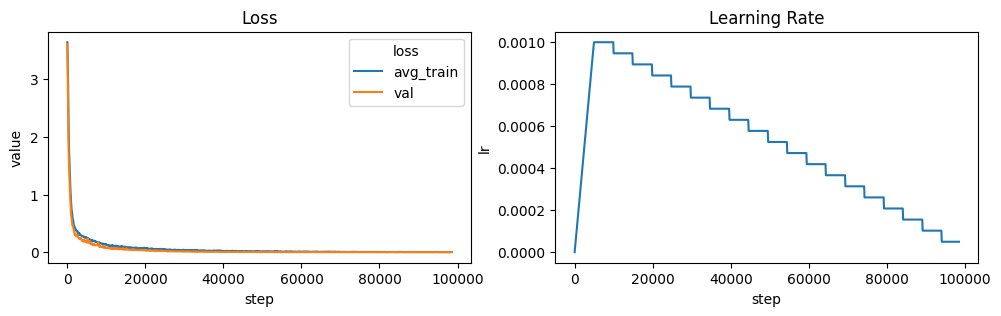

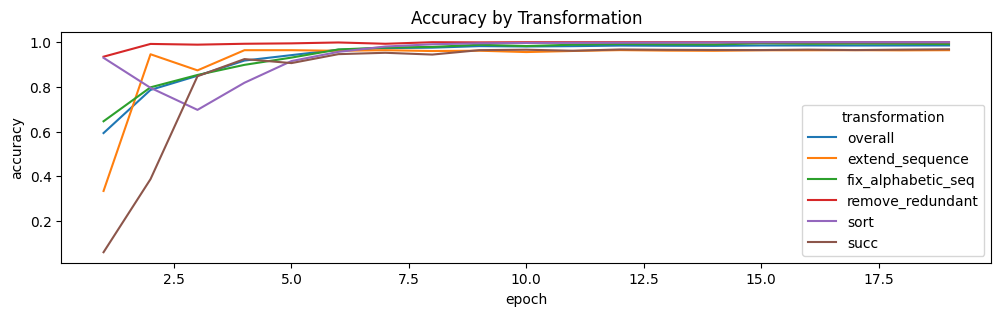

In [ ]:
cp = checkpoint.CheckPoint("../models/MLC_data200k_nopred_nepoch20_best.pt", device=DEVICE)
fig, ax = plt.subplots(1, 2, figsize=(12,3))
ax[0] = cp.plot_loss(ax[0])
_ = ax[0].set_title("Loss")
ax[1] = cp.plot_learning_rate(ax[1])
_ = ax[1].set_title("Learning Rate")
print(f'Best Validation Loss: {cp.checkpoint["best_val_loss"]:.3f}')

val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=["overall","extend_sequence","fix_alphabetic_seq","remove_redundant","sort","succ"], var_name="transformation", value_name="accuracy")
print(f"Best Validation Accuracy: {val_acc.loc[val_acc["transformation"] =="overall","accuracy"].max():.3f}")
_ = plt.figure(figsize=(12,3))
_ = sns.lineplot(val_acc, x="epoch", y="accuracy", hue="transformation")
_ = plt.title("Accuracy by Transformation")